# Comparativo entre os llms SRL2


Comparativo entre os diversos LLMs, vamos analisar os resultados de varabilidade das simulações de cada modelo entre modelos.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import google.generativeai as genai
import openai
import numpy as np
import time
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
### style de execução
tqdm.pandas()

### variaveis de ambiente e conexões

In [3]:
# Carrega as variáveis do arquivo .env
load_dotenv("/data/codigos/.env")

True

In [4]:
for key in os.environ.keys():
    print(f'{key}')

HOSTNAME
HOME
GPG_KEY
PYTHON_SHA256
PATH
LANG
SHELL
PYTHON_VERSION
PWD
VSCODE_CWD
VSCODE_NLS_CONFIG
VSCODE_HANDLES_SIGPIPE
VSCODE_ESM_ENTRYPOINT
VSCODE_HANDLES_UNCAUGHT_ERRORS
REMOTE_CONTAINERS_IPC
REMOTE_CONTAINERS_SOCKETS
SHLVL
_
REMOTE_CONTAINERS
BROWSER
ELECTRON_RUN_AS_NODE
VSCODE_IPC_HOOK_CLI
APPLICATION_INSIGHTS_NO_STATSBEAT
PYDEVD_IPYTHON_COMPATIBLE_DEBUGGING
PYTHONUNBUFFERED
PYTHONIOENCODING
PYTHON_FROZEN_MODULES
PYDEVD_USE_FRAME_EVAL
TERM
CLICOLOR
FORCE_COLOR
CLICOLOR_FORCE
PAGER
GIT_PAGER
MPLBACKEND
KMP_DUPLICATE_LIB_OK
KMP_INIT_AT_FORK
OPENAI_API_KEY_GOV_ANALITICA
GOOGLE_API_KEY_LLMS_PROF_DANILO
ANTROPIC_API_KEY_LLMS
TOGETHER_API_KEY_LLMS
GOOGLE_CLOUD_PROJECT
GOOGLE_CLOUD_REGION


## Carregamento dos datasets

### 1. Datasets da openai

In [5]:
dicto_datasets = {"datasets":["df_result_gpt3", "df_result_gpt4","df_result_gpt41",
                              "df_result_gemini_15_flash","df_result_gemini_pro","df_result_gemini_20_flash",
                              "df_result_claude_haiku_3","df_result_claude_haiku_35","df_result_claude_sonnet_35",
                              "df_result_llama_33_70b","df_result_llama_32_3b","df_result_llama_4_scout_17b"],
                    "caminhos":["/data/codigos/dados/resultados/reproducao_acuracia_openai_gpt_35_final_srl2_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_acuracia_openai_gpt_4_final_srl2_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_acuracia_openai_gpt_41_final_srl2_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_acuracia_gemini_15_flash_final_slr2_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_acuracia_gemini_pro_final_slr2_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_acuracia_gemini_20_flash_final_slr2_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_acuracia_claude_haiku_3_final_slr2_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_acuracia_claude_haiku_35_slr2_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_acuracia_claude_sonnet_35_slr2_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_acuracia_Llama-3.3-70B-Instruct-Turbo-Free_final_srl2_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_acuracia_Llama-3.2-3B-Instruct-Turbo_final_srl2_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_acuracia_Llama-4-Scout-17B-16E-Instruct_final_srl2_v2.csv"],
                    "model":["gpt-3.5-turbo", "gpt-4o","gpt-4.1", "gemini-1.5-flash", "gemini-2.5-flash", 
                             "gemini-2.0-flash","claude-3-haiku-20240307","claude-3-5-haiku-20241022",
                             "claude-3-5-sonnet-20241022","Llama-3.3-70B-Instruct-Turbo-Free",
                             "Llama-3.2-3B-Instruct-Turbo","Llama-4-Scout-17B-16E-Instruct"]}

In [6]:
def load_datasets(dicto_datasets):
    for dataset in dicto_datasets["datasets"]:
        globals()[dataset] = pd.read_csv(dicto_datasets["caminhos"][dicto_datasets["datasets"].index(dataset)])
        globals()[dataset]["model"]=dicto_datasets["model"][dicto_datasets["datasets"].index(dataset)]
        globals()[dataset]["iteraction"] = range(1, len(globals()[dataset])+1)
        globals()[dataset] = globals()[dataset][["model", "iteraction", "Accuracy"]].copy()
        globals()[dataset] = globals()[dataset].rename(columns={"Accuracy":"accuracy"})
        print(f"{dataset} carregado com sucesso")
    

In [7]:
load_datasets(dicto_datasets)

df_result_gpt3 carregado com sucesso
df_result_gpt4 carregado com sucesso
df_result_gpt41 carregado com sucesso
df_result_gemini_15_flash carregado com sucesso
df_result_gemini_pro carregado com sucesso
df_result_gemini_20_flash carregado com sucesso
df_result_claude_haiku_3 carregado com sucesso
df_result_claude_haiku_35 carregado com sucesso
df_result_claude_sonnet_35 carregado com sucesso
df_result_llama_33_70b carregado com sucesso
df_result_llama_32_3b carregado com sucesso
df_result_llama_4_scout_17b carregado com sucesso


In [8]:
df_result_gpt3.head(2)

,model,iteraction,accuracy
0,gpt-3.5-turbo,1,0.375000
1,gpt-3.5-turbo,2,0.367347


In [9]:
df_result_gpt4.head(2)

,model,iteraction,accuracy
0,gpt-4o,1,0.826531
1,gpt-4o,2,0.836735


In [10]:
df_result_gpt41.head(2)

,model,iteraction,accuracy
0,gpt-4.1,1,0.834184
1,gpt-4.1,2,0.829082


In [11]:
df_result_gemini_15_flash.head(2)


,model,iteraction,accuracy
0,gemini-1.5-flash,1,0.767857
1,gemini-1.5-flash,2,0.767857


In [12]:
df_result_gemini_pro.head(2)

,model,iteraction,accuracy
0,gemini-2.5-flash,1,0.795918
1,gemini-2.5-flash,2,0.778061


In [13]:

df_result_gemini_20_flash.head(2)

,model,iteraction,accuracy
0,gemini-2.0-flash,1,0.744898
1,gemini-2.0-flash,2,0.742347


In [14]:
df_result_claude_haiku_3.head(2)

,model,iteraction,accuracy
0,claude-3-haiku-20240307,1,0.806122
1,claude-3-haiku-20240307,2,0.808673


In [15]:
df_result_claude_haiku_35.head(2)

,model,iteraction,accuracy
0,claude-3-5-haiku-20241022,1,0.798469
1,claude-3-5-haiku-20241022,2,0.798469


In [16]:
df_result_claude_sonnet_35.head(2)

,model,iteraction,accuracy
0,claude-3-5-sonnet-20241022,1,0.836735
1,claude-3-5-sonnet-20241022,2,0.834184


In [17]:
df_result_llama_33_70b.head(2)

,model,iteraction,accuracy
0,Llama-3.3-70B-Instruct-Turbo-Free,1,0.668367
1,Llama-3.3-70B-Instruct-Turbo-Free,2,0.668367


In [18]:
df_result_llama_32_3b.head(2)

,model,iteraction,accuracy
0,Llama-3.2-3B-Instruct-Turbo,1,0.67602
1,Llama-3.2-3B-Instruct-Turbo,2,0.67602


In [19]:
df_result_llama_4_scout_17b.head(2)

,model,iteraction,accuracy
0,Llama-4-Scout-17B-16E-Instruct,1,0.678571
1,Llama-4-Scout-17B-16E-Instruct,2,0.676020


In [20]:
# Empilha os datasets para visualização
df_resultados = pd.concat([df_result_gpt3, df_result_gpt4, df_result_gpt41,
                           df_result_gemini_15_flash, 
                           df_result_gemini_pro, 
                           df_result_gemini_20_flash,
                           df_result_claude_haiku_3,
                           df_result_claude_haiku_35,
                           df_result_claude_sonnet_35,
                           df_result_llama_33_70b,
                           df_result_llama_32_3b,
                           df_result_llama_4_scout_17b], axis=0,ignore_index=True)
df_resultados = df_resultados.reset_index(drop=True)
df_resultados.head(2)

,model,iteraction,accuracy
0,gpt-3.5-turbo,1,0.375000
1,gpt-3.5-turbo,2,0.367347


## algumas analises

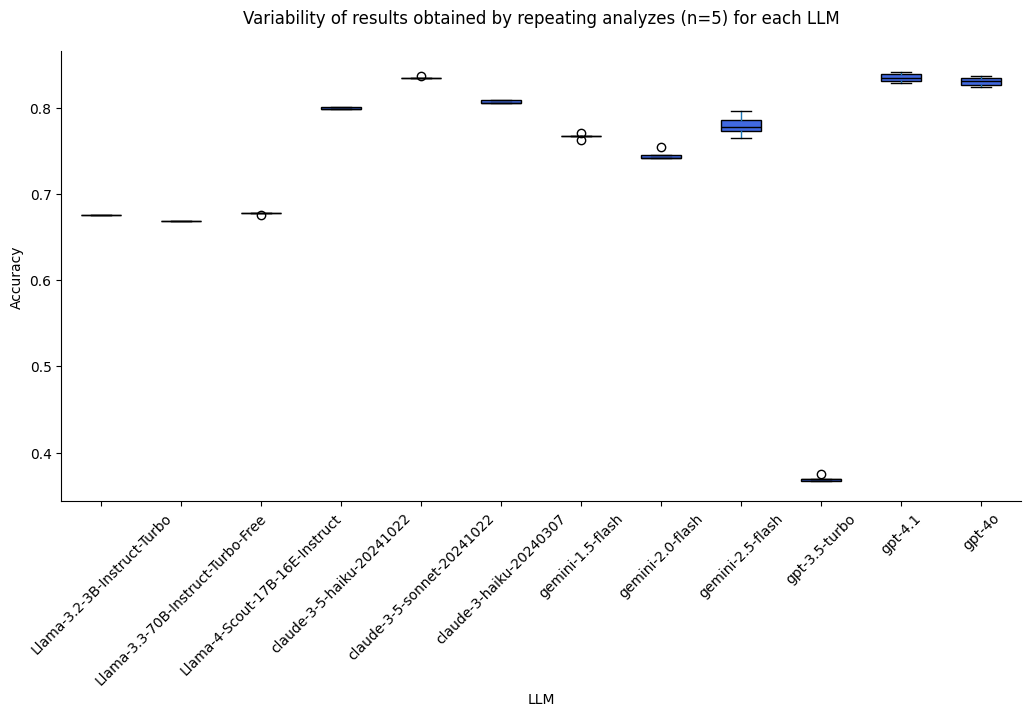

In [21]:
# Cria o boxplot
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
boxplot = df_resultados.boxplot(column='accuracy', by='model', grid=False, patch_artist=True, return_type='dict', ax=ax)

# Define a cor dos boxplots e o contorno em preto
for box in boxplot['accuracy']['boxes']:
    box.set_facecolor('royalblue')
    box.set_edgecolor('black')  # Define o contorno em preto

# Ajusta a espessura e a cor das linhas de mediana
for median in boxplot['accuracy']['medians']:
    median.set_color('black')
    median.set_linewidth(1)

# Ajusta o título e os rótulos
plt.title('Variability of results obtained by repeating analyzes (n=5) for each LLM', pad=20)  # Aumenta o espaço com pad
# Rotacionar os rótulos do eixo x para melhor visualização
plt.xticks(rotation=45)

# Exibir o gráfico
#plt.tight_layout()
plt.suptitle('')
plt.xlabel('LLM')
plt.ylabel('Accuracy')

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Exibe o gráfico
plt.show()

In [22]:
# Calcula as estatísticas desejadas
df_estatisticas = df_resultados.groupby("model").agg(
    mean=("accuracy", "mean"),
    median=("accuracy", "median"),
    std=("accuracy", "std")
).reset_index()

# Calcula os limites inferior e superior
df_estatisticas["lim_inf"] = df_estatisticas["mean"] - df_estatisticas["std"]
df_estatisticas["lim_sup"] = df_estatisticas["mean"] + df_estatisticas["std"]

# Exibe o resultado
df_estatisticas

,model,mean,median,std,lim_inf,lim_sup
0,Llama-3.2-3B-Instruct-Turbo,0.676020,0.676020,0.000000,0.676020,0.676020
1,Llama-3.3-70B-Instruct-Turbo-Free,0.668367,0.668367,0.000000,0.668367,0.668367
2,Llama-4-Scout-17B-16E-Instruct,0.678061,0.678571,0.001141,0.676920,0.679202
3,claude-3-5-haiku-20241022,0.799490,0.798469,0.001397,0.798093,0.800887
4,claude-3-5-sonnet-20241022,0.834694,0.834184,0.001141,0.833553,0.835835
5,claude-3-haiku-20240307,0.807143,0.806122,0.001397,0.805746,0.808540
6,gemini-1.5-flash,0.767347,0.767857,0.002795,0.764552,0.770141
7,gemini-2.0-flash,0.745408,0.742347,0.005530,0.739878,0.750939
8,gemini-2.5-flash,0.779592,0.778061,0.011773,0.767818,0.791365
9,gpt-3.5-turbo,0.369898,0.369898,0.003124,0.366774,0.373022


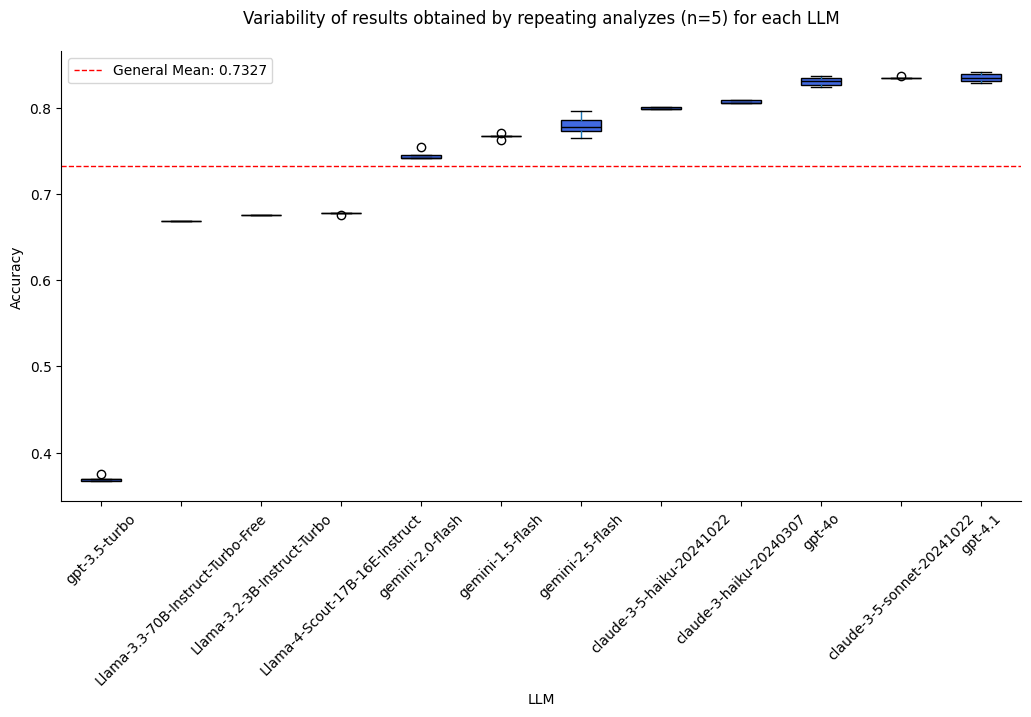

In [23]:
# Ordena o DataFrame em ordem crescente de Accuracy média
df_resultados_sorted = df_resultados.copy()
df_resultados_sorted['model'] = pd.Categorical(df_resultados_sorted['model'], 
                                               categories=df_estatisticas.sort_values('mean')['model'], 
                                               ordered=True)

# Cria o boxplot
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
boxplot = df_resultados_sorted.boxplot(column='accuracy', by='model', grid=False, patch_artist=True, return_type='dict', ax=ax)

# Define a cor dos boxplots e o contorno em preto
for box in boxplot['accuracy']['boxes']:
    box.set_facecolor('royalblue')
    box.set_edgecolor('black')  # Define o contorno em preto

# Ajusta a espessura e a cor das linhas de mediana
for median in boxplot['accuracy']['medians']:
    median.set_color('black')
    median.set_linewidth(1)

# Calcula a média geral das acurácias
general_mean = df_resultados['accuracy'].mean()

# Adiciona a linha da média geral ao gráfico
ax.axhline(general_mean, color='red', linestyle='--', linewidth=1, label=f'General Mean: {general_mean:.4f}')

# Ajusta o título e os rótulos
plt.title('Variability of results obtained by repeating analyzes (n=5) for each LLM', pad=20)  # Aumenta o espaço com pad
# Rotacionar os rótulos do eixo x para melhor visualização
plt.xticks(rotation=45)

# Exibir o gráfico
#plt.tight_layout()
plt.suptitle('')
plt.xlabel('LLM')
plt.ylabel('Accuracy')
plt.legend()

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Exibe o gráfico
plt.show()

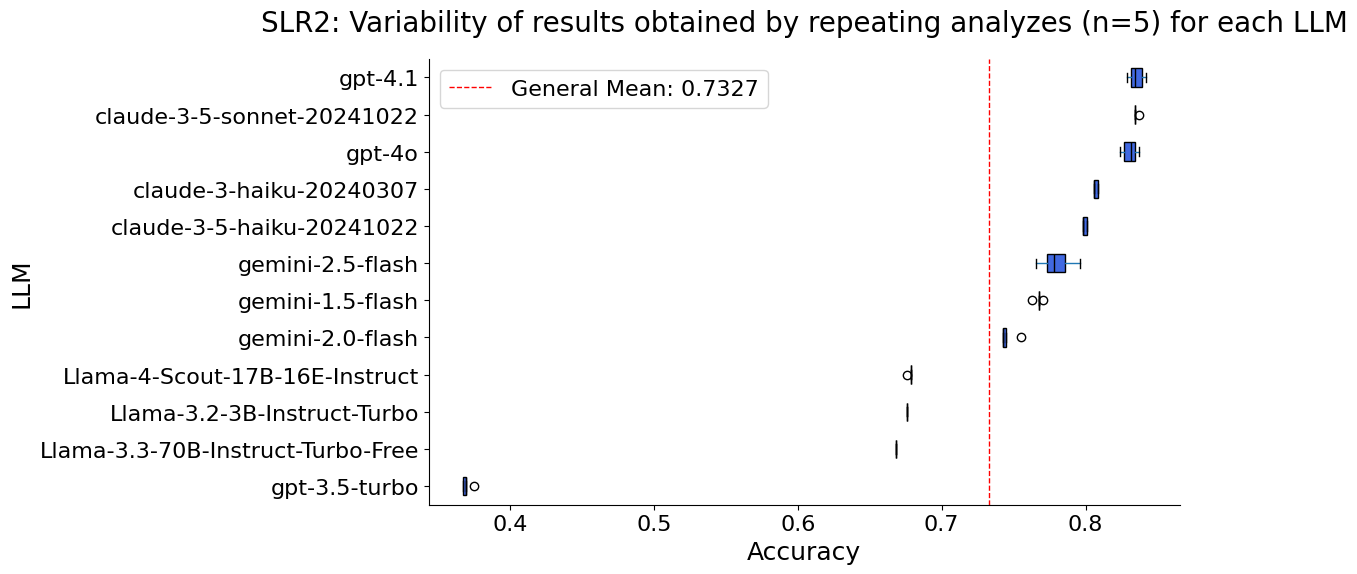

In [39]:
# Ordena o DataFrame em ordem crescente de Accuracy média
df_resultados_sorted = df_resultados.copy()
df_resultados_sorted['model'] = pd.Categorical(
    df_resultados_sorted['model'],
    categories=df_estatisticas.sort_values('mean')['model'],
    ordered=True
)

# Cria o boxplot horizontal (LLMs no eixo Y, Accuracy no eixo X)
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

boxplot = df_resultados_sorted.boxplot(
    column='accuracy',
    by='model',
    vert=False,              # <-- horizontal
    grid=False,
    patch_artist=True,
    return_type='dict',
    ax=ax
)

# Define a cor dos boxplots e o contorno em preto
for box in boxplot['accuracy']['boxes']:
    box.set_facecolor('royalblue')
    box.set_edgecolor('black')

# Ajusta a espessura e a cor das linhas de mediana
for median in boxplot['accuracy']['medians']:
    median.set_color('black')
    median.set_linewidth(1)

# Calcula a média geral das acurácias
general_mean = df_resultados['accuracy'].mean()

# Adiciona a linha da média geral (agora vertical)
ax.axvline(general_mean, color='red', linestyle='--', linewidth=1,
           label=f'General Mean: {general_mean:.4f}')

# Título e rótulos
plt.title('SLR2: Variability of results obtained by repeating analyzes (n=5) for each LLM', pad=20, fontsize=20)  # Aumenta o espaço com pad
plt.suptitle('')  # remove o título automático "accuracy by model"
plt.xlabel('Accuracy', fontsize=18)
plt.ylabel('LLM', fontsize=18)

# Ticks (opcional: ajuste rotação se os nomes forem longos)
plt.yticks(rotation=0)

# Remover bordas desnecessárias
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=16)

plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig('/data/codigos/dados/resultados/figuras/slr2_fase_1_comparativo_llms_horizontal.png', dpi=300)
plt.show()

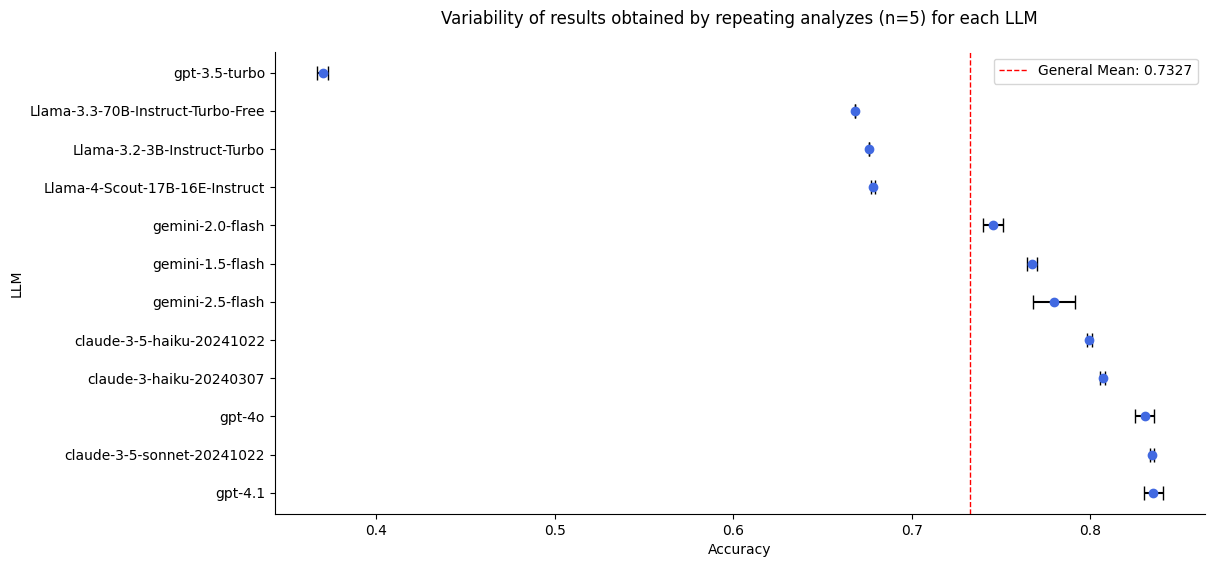

In [25]:
# Ordena o DataFrame em ordem decrescente de accuracy média
df_estatisticas = df_estatisticas.sort_values(by='mean', ascending=False)

# Cria o gráfico de fatores de influência com modelo na vertical e accuracy na horizontal
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

# Plota os pontos centrais (médias) e as barras de erro (limites inferior e superior)
ax.errorbar(df_estatisticas['mean'], df_estatisticas['model'], 
            xerr=[df_estatisticas['mean'] - df_estatisticas['lim_inf'], 
                  df_estatisticas['lim_sup'] - df_estatisticas['mean']], 
            fmt='o', color='royalblue', ecolor='black', capsize=5)

# Calcula a média das médias
media_das_medias = df_estatisticas['mean'].mean()

# Traça a linha horizontal representando a média das médias
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_das_medias:.4f}')

# Ajusta o título e os rótulos
plt.title("Variability of results obtained by repeating analyzes (n=5) for each LLM", pad=20)
plt.ylabel('LLM')
plt.xlabel('Accuracy')
plt.legend()

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Exibe o gráfico
plt.show()

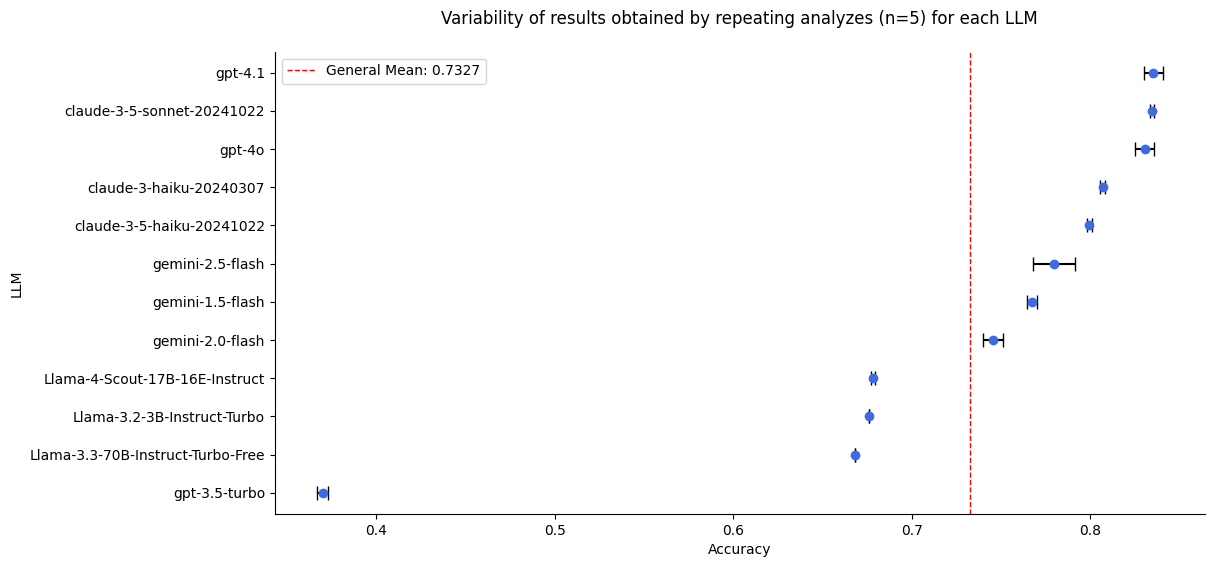

In [26]:
# Ordena o DataFrame em ordem decrescente de accuracy média
df_estatisticas = df_estatisticas.sort_values(by='mean', ascending=True)

# Cria o gráfico de fatores de influência com modelo na vertical e accuracy na horizontal
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

# Plota os pontos centrais (médias) e as barras de erro (limites inferior e superior)
ax.errorbar(df_estatisticas['mean'], df_estatisticas['model'], 
            xerr=[df_estatisticas['mean'] - df_estatisticas['lim_inf'], 
                  df_estatisticas['lim_sup'] - df_estatisticas['mean']], 
            fmt='o', color='royalblue', ecolor='black', capsize=5)

# Calcula a média das médias
media_das_medias = df_estatisticas['mean'].mean()

# Traça a linha horizontal representando a média das médias
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_das_medias:.4f}')

# Ajusta o título e os rótulos
plt.title("Variability of results obtained by repeating analyzes (n=5) for each LLM", pad=20)
plt.ylabel('LLM')
plt.xlabel('Accuracy')
plt.legend()

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Exibe o gráfico
plt.show()

In [27]:
df_estatisticas.sort_values(by="mean", ascending=False).reset_index(drop=True)

,model,mean,median,std,lim_inf,lim_sup
0,gpt-4.1,0.835204,0.834184,0.005290,0.829914,0.840494
1,claude-3-5-sonnet-20241022,0.834694,0.834184,0.001141,0.833553,0.835835
2,gpt-4o,0.830612,0.831633,0.005290,0.825322,0.835902
3,claude-3-haiku-20240307,0.807143,0.806122,0.001397,0.805746,0.808540
4,claude-3-5-haiku-20241022,0.799490,0.798469,0.001397,0.798093,0.800887
5,gemini-2.5-flash,0.779592,0.778061,0.011773,0.767818,0.791365
6,gemini-1.5-flash,0.767347,0.767857,0.002795,0.764552,0.770141
7,gemini-2.0-flash,0.745408,0.742347,0.005530,0.739878,0.750939
8,Llama-4-Scout-17B-16E-Instruct,0.678061,0.678571,0.001141,0.676920,0.679202
9,Llama-3.2-3B-Instruct-Turbo,0.676020,0.676020,0.000000,0.676020,0.676020


### Olhando as variabilidades das llms

In [28]:
df_resultados.head()

,model,iteraction,accuracy
0,gpt-3.5-turbo,1,0.375000
1,gpt-3.5-turbo,2,0.367347
2,gpt-3.5-turbo,3,0.369898
3,gpt-3.5-turbo,4,0.367347
4,gpt-3.5-turbo,5,0.369898


In [29]:
# Vamos criar uma nova coluna chamada family que vai dizer em qual família cada modelo pertence
# para isto vamos criar um dicionario e depois aplicar sobre o dataframe
dic_family = {
    "gpt-3.5-turbo": "Openai GPT",
    "gpt-4o": "Openai GPT",
    "gpt-4.1": "Openai GPT",
    "gemini-1.5-flash": "Google Gemini",
    "gemini-2.5-flash": "Google Gemini",
    "gemini-2.0-flash": "Google Gemini",
    "claude-3-haiku-20240307": "Anthropic Claude",
    "claude-3-5-haiku-20241022": "Anthropic Claude",
    "claude-3-5-sonnet-20241022": "Anthropic Claude",
    "Llama-3.3-70B-Instruct-Turbo-Free": "Meta Llama",
    "Llama-3.2-3B-Instruct-Turbo": "Meta Llama",
    "Llama-4-Scout-17B-16E-Instruct": "Meta Llama"
}
df_resultados["family"] = df_resultados["model"].map(dic_family)

In [30]:
#  vendo se algum modelo ficou de fora
df_resultados["family"].isna().sum()

np.int64(0)

In [31]:
# olhando qual ficou de fora
df_resultados[df_resultados["family"].isna()]

,model,iteraction,accuracy,family


In [32]:
# agrupando por family e calculando a mean median, std, lim_inf, lim_sup
df_estatisticas_family = df_resultados.groupby("family").agg(
    mean=("accuracy", "mean"),
    median=("accuracy", "median"),
    std=("accuracy", "std")
).reset_index()

# Calcula os limites inferior e superior
df_estatisticas_family["lim_inf"] = df_estatisticas_family["mean"] - df_estatisticas_family["std"]
df_estatisticas_family["lim_sup"] = df_estatisticas_family["mean"] + df_estatisticas_family["std"]

# Exibe o resultado
df_estatisticas_family.sort_values(by="std", ascending=False).reset_index(drop=True)

,family,mean,median,std,lim_inf,lim_sup
0,Openai GPT,0.678571,0.829082,0.225976,0.452596,0.904547
1,Google Gemini,0.764116,0.767857,0.016274,0.747842,0.780389
2,Anthropic Claude,0.813776,0.806122,0.015696,0.798080,0.829471
3,Meta Llama,0.674150,0.676020,0.004362,0.669788,0.678512


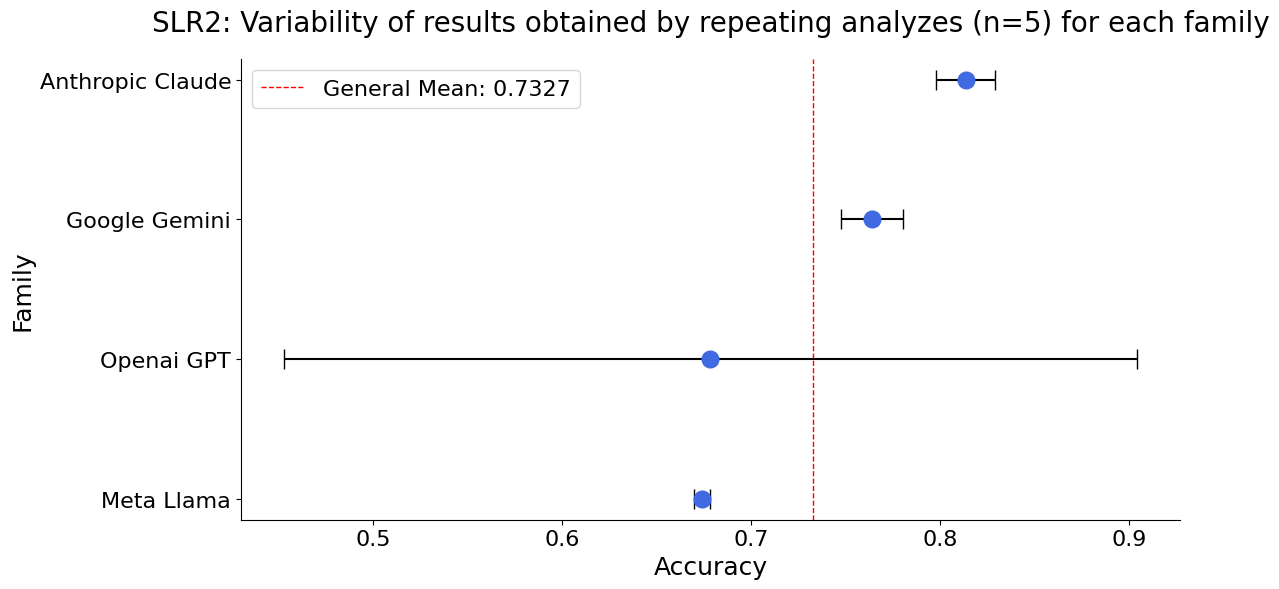

In [43]:
# Ordena o DataFrame em ordem decrescente de accuracy média
df_estatisticas_family = df_estatisticas_family.sort_values(by='mean', ascending=True)

# Cria o gráfico de fatores de influência com modelo na vertical e accuracy na horizontal
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

# Plota os pontos centrais (médias) e as barras de erro (limites inferior e superior)
ax.errorbar(df_estatisticas_family['mean'], df_estatisticas_family['family'], 
            xerr=[df_estatisticas_family['mean'] - df_estatisticas_family['lim_inf'], 
                  df_estatisticas_family['lim_sup'] - df_estatisticas_family['mean']], 
            fmt='o', color='royalblue', ecolor='black', capsize=7, markersize=12)

# Calcula a média das médias
media_das_medias = df_estatisticas_family['mean'].mean()

# Traça a linha horizontal representando a média das médias
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_das_medias:.4f}')

# Ajusta o título e os rótulos
plt.title("SLR2: Variability of results obtained by repeating analyzes (n=5) for each family", pad=20, fontsize=20)
plt.ylabel('Family', fontsize=18)
plt.xlabel('Accuracy', fontsize=18)
plt.legend(fontsize=16)

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig('/data/codigos/dados/resultados/figuras/slr2_fase_1_comparativo_familia_horizontal.png',
            dpi=300, bbox_inches='tight')

# Exibe o gráfico
plt.show()